In [1]:
import numpy as np
import math 
import matplotlib.pyplot as plt
import csv
from csv import writer
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator

In [2]:
# Change the csv file name below, without .csv
# comma separated data

In [3]:
filename='temperature_log_2025-01-01T18-41-11' # new year run - SMA cable test 1

In [4]:
data_temp = np.loadtxt(filename+".txt", usecols=1, skiprows=4, dtype='float',delimiter=",") 
data_timestamp = np.loadtxt(filename+".txt", usecols=1, skiprows=4, dtype='str') 
data_date =  np.loadtxt(filename+".txt", usecols=0, skiprows=4, dtype='str') 


In [5]:
time_stamps=np.empty(len(data_timestamp), dtype = 'S20')
for j in range(len(data_timestamp)):
    count=-1
    for i in data_timestamp[j]:
        count+=1
        if i==',':
            #print(count)
            time_stamps[j]=data_timestamp[j][:count]
        
#data_timestamp[0]

In [51]:
### Find timestamp index
counter=0
for i in range(len(time_stamps)):
    #print(i)
    if str(time_stamps[i],'utf-8')=='20:07:23':
        print(counter)
        break
    counter+=1

counter2=0
for i in range(len(time_stamps)):
    #print(i)
    if str(time_stamps[i],'utf-8')=='23:31:07':
        print(counter2)
        break
    counter2+=1

print('Temp at timestamp',str(time_stamps[counter],'utf-8'),'is',data_temp[counter])

2
1524
Temp at timestamp 20:07:23 is 297.6


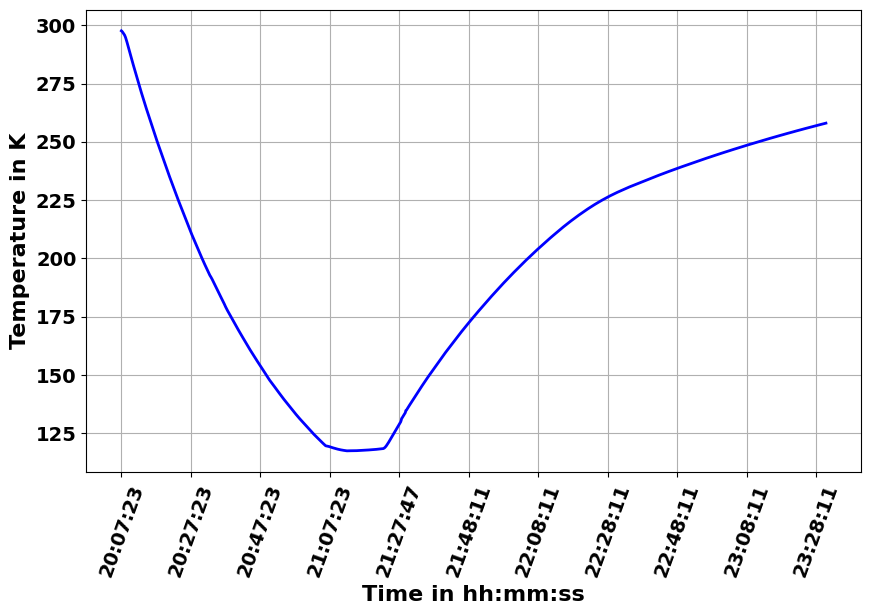

In [52]:
start_t=counter
stop_t=counter2
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps[start_t:stop_t],data_temp[start_t:stop_t],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Time in hh:mm:ss",fontsize='16', fontweight='bold')
plt.ylabel("Temperature in K",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.show()

In [45]:
counter=0
filename='../test_logs/1jan2025'
pressure_readings=np.array([])
date_time=np.array([])
with open(filename+'.xls', mode ='r')as file:
  csvFile = csv.reader(file)
  for lines in csvFile:
      counter+=1
      if(counter>6):
          lines1=lines[0].split('\t')
          pressure_readings=np.append(pressure_readings,10**3*float(lines1[0]))
          date_time=np.append(date_time,lines1[7])

In [49]:
### Find timestamp index
counterp=0
for i in range(len(time_stamps_pressure)):
    #print(i)
    if str(time_stamps_pressure[i],'utf-8')=='20.07.23':
        print(counterp)
        break
    counterp+=1
counterp2=0
for i in range(len(time_stamps_pressure)):
    #print(i)
    if str(time_stamps_pressure[i],'utf-8')=='23.31.04':
        print(counterp2)
        break
    counterp2+=1


print('Pressure at timestamp',str(time_stamps_pressure[counterp],'utf-8'),'is',pressure_readings[counterp],'mbar')

5837
7837
Pressure at timestamp 20.07.23 is 0.015000000000000001 mbar


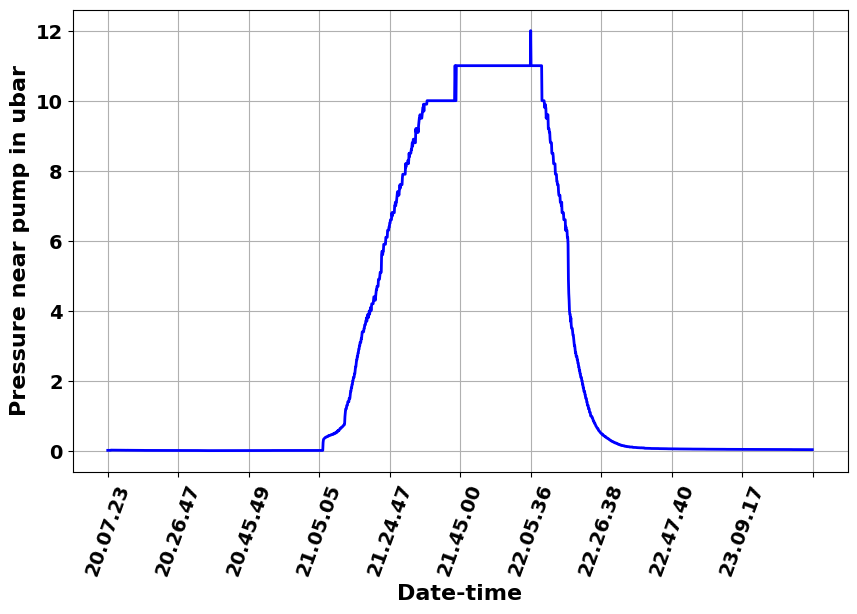

In [50]:
start_p=counterp
stop_p=counterp2
fig,ax=plt.subplots(figsize=(10,6))
plt.plot(time_stamps_pressure[start_p:stop_p],pressure_readings[start_p:stop_p],'b-',linewidth=2)
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
plt.xticks(rotation=70)
#plt.title("Cryo-cooler temperature curve",fontsize='large', fontweight='bold')#- 13/09/24")
plt.xlabel("Date-time",fontsize='16', fontweight='bold')
plt.ylabel("Pressure near pump in ubar",fontsize='16', fontweight='bold')
plt.xticks(fontsize = 14, fontweight='bold')
plt.yticks(fontsize = 14, fontweight='bold')
plt.grid()
plt.show()

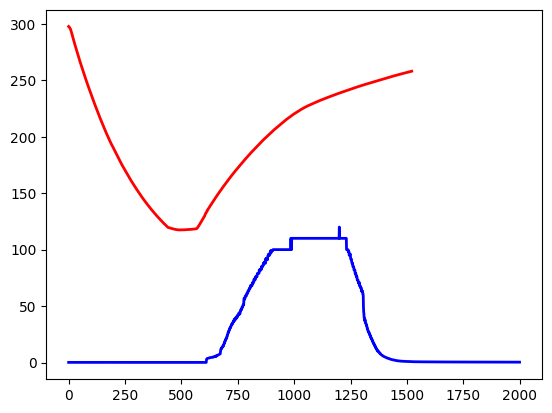

In [54]:
plt.plot(10*pressure_readings[start_p:stop_p],'b-',linewidth=2)
plt.plot(data_temp[start_t:stop_t],'r-',linewidth=2)

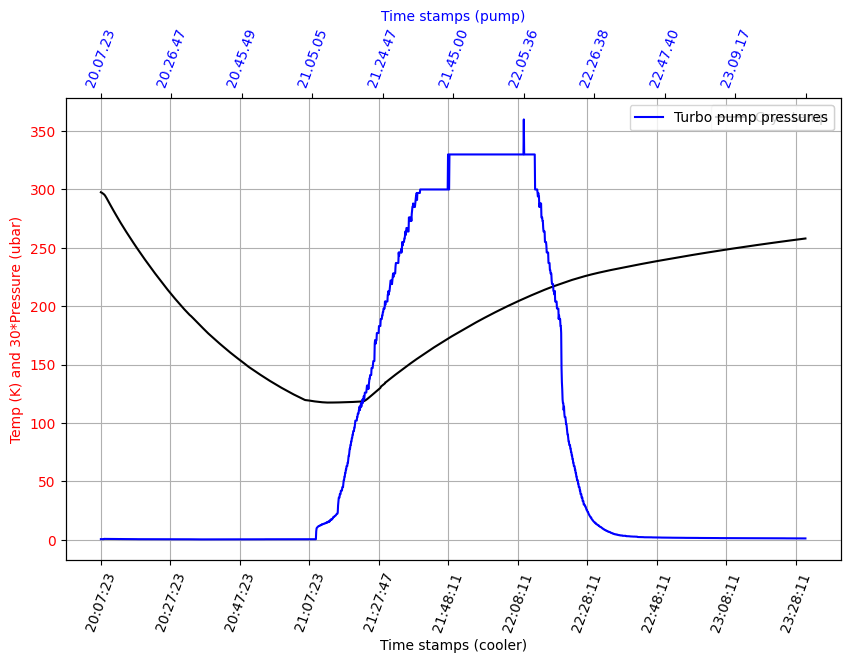

In [91]:

# Create a figure and the first axis (ax1)
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot the first dataset (y1 vs x1) on the primary axes (bottom x-axis)
ax1.plot(time_stamps[start_t:stop_t], data_temp[start_t:stop_t], 'k-', label='Cryo temp')
ax1.set_xlabel('Time stamps (cooler)')
ax1.set_ylabel('Temp (K) and 30*Pressure (ubar)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.xaxis.set_major_locator(MaxNLocator(nbins=14))
plt.xticks(rotation=70)
plt.grid()
plt.legend()
# Create a second axes that shares the same y-axis but with a different x-axis (top x-axis)
ax2 = ax1.twiny()  # Create the second x-axis (top)
ax2.plot(time_stamps_pressure[start_p:stop_p], 30*pressure_readings[start_p:stop_p], 'b-', label='Turbo pump pressures')
ax2.set_xlabel('Time stamps (pump)', color='b')
ax2.tick_params(axis='x', labelcolor='b')
ax2.xaxis.set_major_locator(MaxNLocator(nbins=14))
ax2.tick_params(axis='x', rotation=70)
#plt.grid()
# Show the plot
plt.legend()
plt.show()


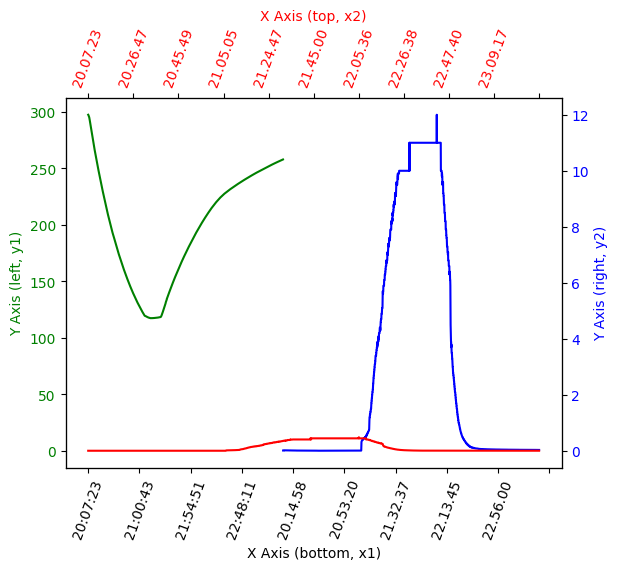

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Create some data
x1 =time_stamps[start_t:stop_t]
y1 = data_temp[start_t:stop_t]

x2 = time_stamps_pressure[start_p:stop_p]
y2 = pressure_readings[start_p:stop_p]

# Create the figure
fig, ax1 = plt.subplots()

# Plot the first dataset (y1 vs x1) on the primary axes (bottom x-axis, left y-axis)
ax1.plot(x1, y1, 'g-', label='sin(x1)')
ax1.set_xlabel('X Axis (bottom, x1)')
ax1.set_ylabel('Y Axis (left, y1)', color='g')
ax1.tick_params(axis='y', labelcolor='g')

# Set the x-ticks to show only 12 ticks for ax1 (bottom x-axis)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=12))

# Rotate the labels on the bottom x-axis by 70 degrees
plt.xticks(rotation=70)

# Create a second y-axis (right y-axis) that is linked to the top x-axis
ax2 = ax1.twinx()  # Create the second y-axis (right side)
ax2.plot(x2, y2, 'b-', label='cos(x2)')
ax2.set_ylabel('Y Axis (right, y2)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Set the x-ticks to show only 12 ticks for ax2 (top x-axis)
ax2.xaxis.set_major_locator(MaxNLocator(nbins=12))

# Create a second x-axis at the top that is linked to the bottom x-axis
ax3 = ax1.twiny()  # Create the second x-axis (top)
ax3.plot(x2, y2, 'r-', label='cos(x2) (top)')
ax3.set_xlabel('X Axis (top, x2)', color='r')
ax3.tick_params(axis='x', labelcolor='r')
ax3.xaxis.set_major_locator(MaxNLocator(nbins=12))
# Rotate the labels on the top x-axis by 70 degrees
ax3.tick_params(axis='x', rotation=70)

# Show the plot
plt.show()


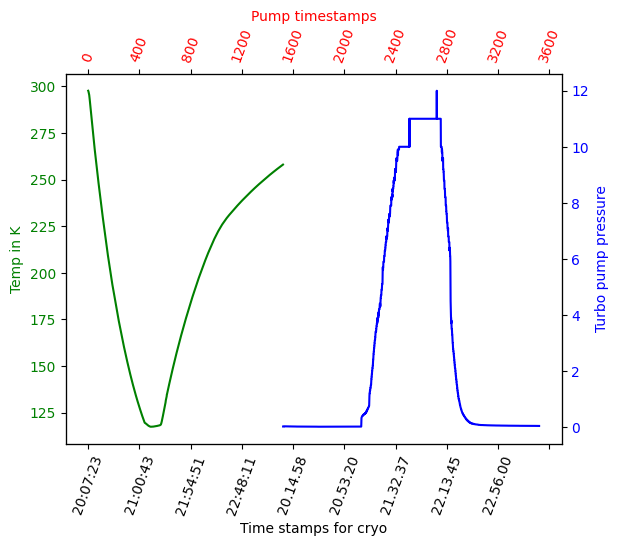

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Create some data
x1 =time_stamps[start_t:stop_t]
y1 = data_temp[start_t:stop_t]

x2 = time_stamps_pressure[start_p:stop_p]
y2 = pressure_readings[start_p:stop_p]

# Create the figure and primary axis (ax1)
fig, ax1 = plt.subplots()

# Plot the first dataset (y1 vs x1) on ax1 (bottom x-axis, left y-axis)
ax1.plot(x1, y1, 'g-', label='Cryo cooler temp')
ax1.set_xlabel('Time stamps for cryo')
ax1.set_ylabel('Temp in K', color='g')
ax1.tick_params(axis='y', labelcolor='g')

# Set the x-ticks to show only 12 ticks for ax1 (bottom x-axis)
ax1.xaxis.set_major_locator(MaxNLocator(nbins=12))

# Rotate the labels on the bottom x-axis by 70 degrees
plt.xticks(rotation=70)

# Create a second y-axis (right y-axis) that is linked to the top x-axis
ax2 = ax1.twinx()  # Create the second y-axis (right side)

# Plot only the second dataset (y2 vs x2) on ax2 (right y-axis)
ax2.plot(x2, y2, 'b-', label='Pressure')
ax2.set_ylabel('Turbo pump pressure', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Create a second x-axis at the top that is linked to the bottom x-axis
ax3 = ax1.twiny()  # Create the second x-axis (top)
ax3.set_xlabel('Pump timestamps', color='r')
ax3.tick_params(axis='x', labelcolor='r')

# Manually set the top x-axis limits to match the x2 data
ax3.set_xlim(ax2.get_xlim())  # Set top x-axis range to match the right y-axis range (x2)

# Set the x-ticks to show only 12 ticks for ax3 (top x-axis)
ax3.xaxis.set_major_locator(MaxNLocator(nbins=12))

# Rotate the labels on the top x-axis by 70 degrees
ax3.tick_params(axis='x', rotation=70)

# Show the plot
plt.show()


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('S20'), dtype('S20')) -> None

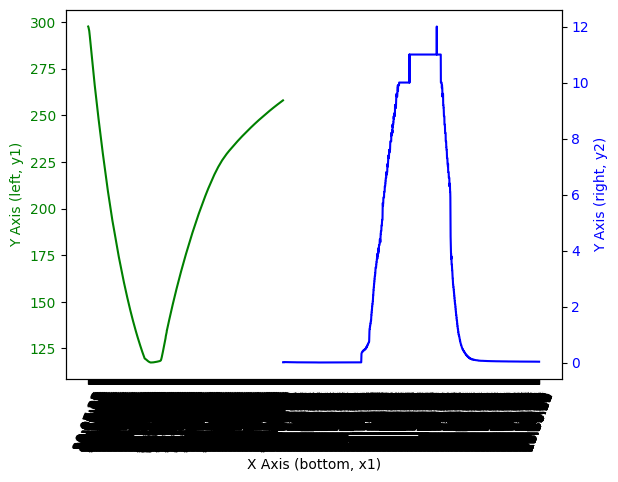

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Create some data
x1 =time_stamps[start_t:stop_t]
y1 = data_temp[start_t:stop_t]

x2 = time_stamps_pressure[start_p:stop_p]
y2 = pressure_readings[start_p:stop_p]


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

# Create some example timestamp data





# Create the figure and primary axis (ax1)
fig, ax1 = plt.subplots()

# Plot the first dataset (y1 vs x1) on ax1 (bottom x-axis, left y-axis)
ax1.plot(x1, y1, 'g-', label='sin(x1)')
ax1.set_xlabel('X Axis (bottom, x1)')
ax1.set_ylabel('Y Axis (left, y1)', color='g')
ax1.tick_params(axis='y', labelcolor='g')

# Rotate the labels on the bottom x-axis by 70 degrees
plt.xticks(rotation=70)

# Create a second y-axis (right y-axis) that is linked to the top x-axis
ax2 = ax1.twinx()  # Create the second y-axis (right side)

# Plot the second dataset (y2 vs x2) on ax2 (right y-axis)
ax2.plot(x2, y2, 'b-', label='cos(x2)')  # Pressure data vs x2
ax2.set_ylabel('Y Axis (right, y2)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Manually set ax2's x-axis to match x2 (to avoid using x1)
ax2.set_xlabel('X Axis (top, x2)', color='r')
ax2.set_xlim([x2.min(), x2.max()])  # Set the limits for ax2's x-axis to match x2

# Create a second x-axis at the top that is linked to the bottom x-axis
ax3 = ax1.twiny()  # Create the second x-axis (top)
ax3.set_xlabel('X Axis (top, x2)', color='r')
ax3.tick_params(axis='x', labelcolor='r')

# Manually set the top x-axis limits to match the x2 data
ax3.set_xlim([x2.min(), x2.max()])  # Set top x-axis range to match x2

# Set the x-ticks to show only 12 ticks for ax3 (top x-axis)
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=5))  # Adjust interval for x2's top axis

# Rotate the labels on the top x-axis by 70 degrees
ax3.tick_params(axis='x', rotation=70)

# Format the datetime labels on the x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Show the plot
plt.show()

